## DS-450 Capstone EDA and Modeling

### Variables:
##### This time series data is formatted with each of these variables, for each repective department, for that 
##### given week for each week in 2023-25:
- **Date**: The only non-repeating variable; tells the week and year of the observation. The dtype is datetime64.

- **Actual Sales**: Sales in dollars from the given department.

- **Actual Sales per Labor Hour**: Sales in dollars per actual hour of labor.

- **Actual AHR**: Average hourly rate.

- **Actual Hours**: The actual number of hours expended by that department.

- **Actual % Effective**: Percentage of actual hours that are productive.

- **Actual Overtime Hours**: Number of hours overtime.

- **Actual Overtime Wages**: Amount of wages paid to overtime hours.

- **Actual Overtime %**: Percent of total hours which are overtime.

- **Forecast Fixed Hours**: Forecasted future fixed hours (forecasting 2 weeks ahead).

- **Forecast Variable Hours**: Forecasted variable hours.

- **Earned Hours @ 100%**: The hours earned and delegated to that department a given week.ven week.

##### Most of these variables are of dtype float64 with exception to 25 observations, which I
##### attribute to inconsistent data entry and should not negetively affect the EDA/Modeling- 
- 
- 



In [1]:
#data.dtypes.value_counts()

### Questions and Ideas to Consider:
- Labor Productivity: Are actual hours, given sales, alligning with demand? 
- Labor Efficiency: Earned Hours @ 100% / Actual Hours = Efficiency; was that week over or underscheduled or perfectly scheduled?
- Overtime: Given variables, will overtme occur in a given week or no? 
- POS: Does more/less SCO hours correlate with more/less register hours? 
- Can hours required be predicted given sales?

### Preprocessing

In [2]:
#Importing libraries for processing and modeling. 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


In [4]:
data = pd.read_excel('Mrdak_339Data.xlsx', sheet_name = 'Formatted Data')

data.head(3)

,Date,Front End Actual Sales,Actual Sales per Labor Hour,Actual AHR,Actual Hours,Actual % Effective,Actual Overtime Hours,Actual Overtime Wages,Actual Overtime %,Forecast Fixed Hours,...,Actual Sales per Labor Hour.31,Actual AHR.31,Actual Hours.31,Actual % Effective.31,Actual Overtime Hours.31,Actual Overtime Wages.31,Actual Overtime %.31,Forecast Fixed Hours.31,Forecast Variable Hours.31,Earned Hours @ 100%.31
0,2025 W52,279759.70,381.273867,17.347023,733.75,1.018126,10.5,324.60,0.013623,427.868,...,262.726048,19.567576,3305.169,1.119650,77.67,2461.46,0.022873,1486.910,2405.520,3700.632
1,2025 W51,630969.57,759.746623,17.593305,830.50,1.136783,12.0,414.02,0.013348,432.523,...,433.772959,19.685112,3971.580,1.074125,140.25,4433.28,0.034364,1524.371,2324.092,4265.974
2,2025 W50,381923.73,427.925748,17.563818,892.50,0.877812,25.5,822.01,0.026323,428.358,...,298.639510,19.555287,4044.500,0.981083,145.50,4473.35,0.035045,1518.424,2408.436,3967.990


In [5]:
print(f'The data is {data.shape[0]} rows by {data.shape[1]} columns.')

The data is 159 rows by 353 columns.


In [6]:
missing_percentage = (data.isnull().sum() / len(data))
((missing_percentage * 100).sort_values(ascending=False)).map(lambda x: f"{x:.2f}%")

Date                          0.00%
Floral Actual Sales           0.00%
Forecast Variable Hours.21    0.00%
Forecast Fixed Hours.21       0.00%
Actual Overtime %.21          0.00%
                              ...  
Actual Overtime Hours.10      0.00%
Actual % Effective.10         0.00%
Actual Hours.10               0.00%
Actual AHR.10                 0.00%
Earned Hours @ 100%.31        0.00%
Length: 353, dtype: object

In [7]:
#for col in data.columns:
    #print(col)

In [8]:
#Dropping columns related to coffee, fuel, and grocery/gm combined. 
data = data.drop([
'Coffee Actual Sales',
'Actual Sales per Labor Hour.22',
'Actual AHR.22',
'Actual Hours.22',
'Actual % Effective.22',
'Actual Overtime Hours.22',
'Actual Overtime Wages.22',
'Actual Overtime %.22',
'Forecast Fixed Hours.22',
'Forecast Variable Hours.22',
'Earned Hours @ 100%.22',
'Without Fuel Actual Sales',
'Actual Sales per Labor Hour.29',
'Actual AHR.29',
'Actual Hours.29',
'Actual % Effective.29',
'Actual Overtime Hours.29',
'Actual Overtime Wages.29',
'Actual Overtime %.29',
'Forecast Fixed Hours.29',
'Forecast Variable Hours.29',
'Earned Hours @ 100%.29',
'Fuel Actual Sales',
'Actual Sales per Labor Hour.30',
'Actual AHR.30',
'Actual Hours.30',
'Actual % Effective.30',
'Actual Overtime Hours.30',
'Actual Overtime Wages.30',
'Actual Overtime %.30',
'Forecast Fixed Hours.30',
'Forecast Variable Hours.30',
'Earned Hours @ 100%.30',
'Grocery & HBC/GM Actual Sales',
'Actual Sales per Labor Hour.14',
'Actual AHR.14',
'Actual Hours.14',
'Actual % Effective.14',
'Actual Overtime Hours.14',
'Actual Overtime Wages.14',
'Actual Overtime %.14',
'Forecast Fixed Hours.14',
'Forecast Variable Hours.14',
'Earned Hours @ 100%.14'], axis = 1)

#for col in data.columns:
    #print(col)

In [9]:
print(f'The data is now {data.shape[0]} rows by {data.shape[1]} columns.')

The data is now 159 rows by 309 columns.


### Analysis

In [10]:
### Note to self dont run the cell below more than once w/o restarting the kernel

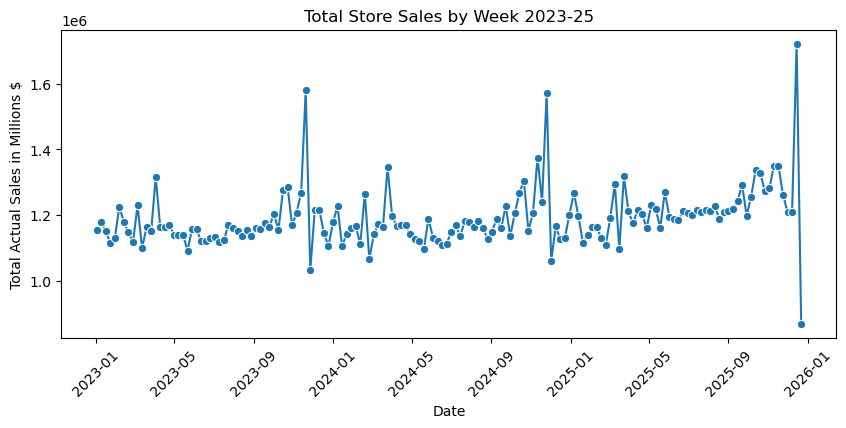

In [11]:
#Converting the values in 'Date' into a presentable format
#Removing 'Average' from Date. 
data = data[data['Date'].str.strip() != 'Average']
data["Date"] = pd.to_datetime(data["Date"] + "-1", format = "%G W%V-%u")
data = data.sort_values("Date")
#Generating the Lineplot
plt.figure(figsize = (10, 4))

sns.lineplot(
    x = "Date",
    y = "Total Actual Sales",
    data = data,
    marker = "o" 
)
plt.title('Total Store Sales by Week 2023-25')
plt.ylabel('Total Actual Sales in Millions $')
plt.xticks(rotation = 45)
plt.show()


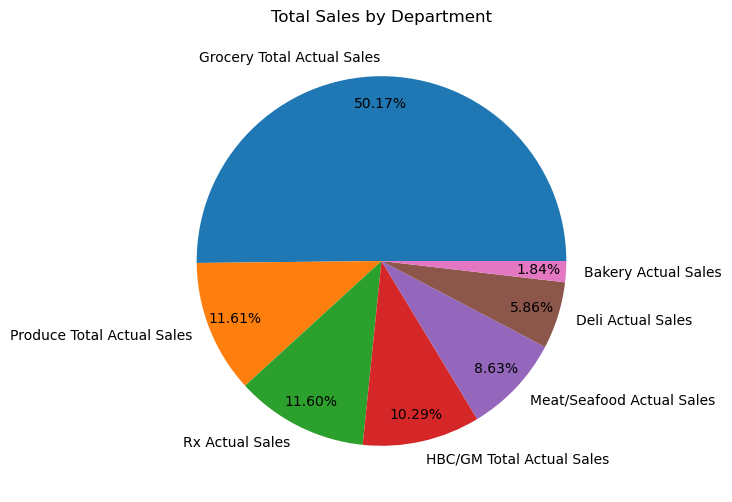

In [12]:
data[['Grocery Total Actual Sales', 'HBC/GM Total Actual Sales', 'Produce Total Actual Sales',\
      'Meat/Seafood Actual Sales', 'Deli Actual Sales', 'Bakery Actual Sales', 'Rx Actual Sales']].sum().sort_values(ascending=False)\
.plot(kind='pie',figsize=(8,6),title="Total Sales by Department",
    pctdistance = 0.85,
    labeldistance = 1.1,
    autopct = '%1.2f%%')
plt.show()

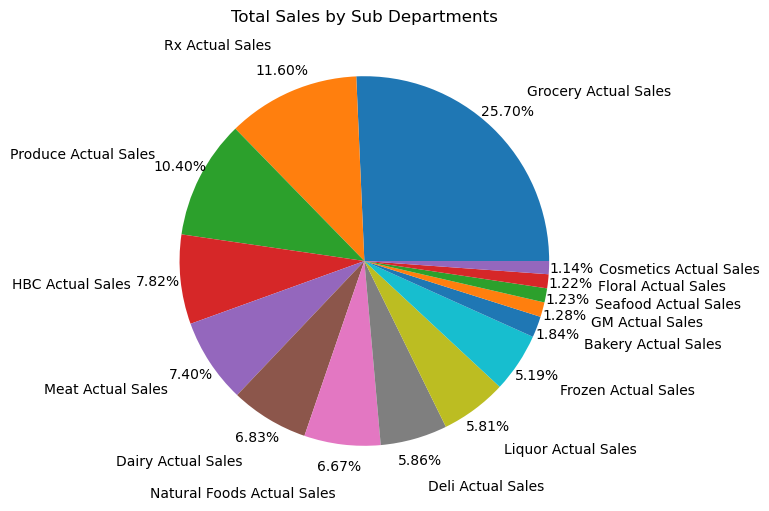

In [13]:
data[['Grocery Actual Sales', 'Dairy Actual Sales', 'Frozen Actual Sales', 'Liquor Actual Sales', 'Natural Foods Actual Sales',\
      'HBC Actual Sales', 'Cosmetics Actual Sales', 'GM Actual Sales', 'Produce Actual Sales', 'Floral Actual Sales',\
      'Meat Actual Sales', 'Seafood Actual Sales', 'Deli Actual Sales', 'Bakery Actual Sales', 'Rx Actual Sales']].sum().sort_values(ascending=False)\
.plot(kind='pie',figsize=(8,6),title="Total Sales by Sub Departments",
    pctdistance = 1.12,
    labeldistance = 1.27,
    autopct = '%1.2f%%')
plt.show()

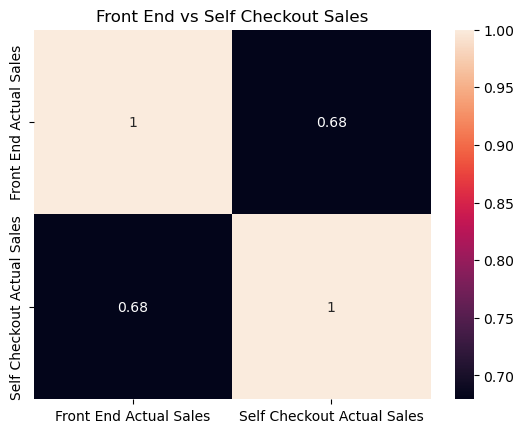

In [14]:
corr=data[['Front End Actual Sales','Self Checkout Actual Sales']].corr()

sns.heatmap(corr,annot=True)
plt.title("Front End vs Self Checkout Sales")
plt.show()

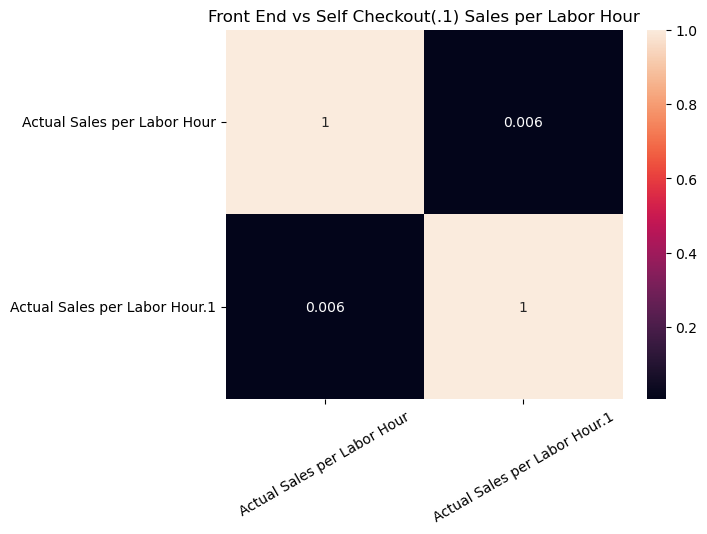

In [15]:
corr=data[['Actual Sales per Labor Hour','Actual Sales per Labor Hour.1']].corr()

sns.heatmap(corr,annot=True)
plt.title("Front End vs Self Checkout(.1) Sales per Labor Hour")
plt.xticks(rotation = 30)
plt.show()

Correlation matrices show there is a strong correlation between front end and sco total sales,
but no correlation between sales per labor hour...

### Random Forest Regression Model

In [16]:
#Question to answer with this model is: Can I predict the actual hours consumed in a given week?
#First need to separate 'Date' into weeks, months, and years, into a datatype that is interpretable for the model. 

data['week'] = data['Date'].dt.isocalendar().week
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year
#isocalendar is week counting in pandas
#.dt to convert into specified date/time

#print(data[['Date', 'week', 'month', 'year']].head(-5))

In [17]:
print(data[['week', 'month', 'year']].dtypes)

week     UInt32
month     int32
year      int32
dtype: object


In [18]:
#Excluding 'Date', but incorporating its week, month, & year.
X = data[['week', 'month', 'year', 'Total Actual Sales', 'Actual Sales per Labor Hour.31', 'Forecast Fixed Hours.31', 'Forecast Variable Hours.31']]
y = data['Actual Hours.31']


In [19]:
#Actual Hours Forest
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .20, random_state = 42)
X_train.info()
#Recall the random_state ensures the same split of data, but in forest, rs goes in model not data split.

<class 'pandas.core.frame.DataFrame'>
Index: 124 entries, 100 to 54
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   week                            124 non-null    UInt32 
 1   month                           124 non-null    int32  
 2   year                            124 non-null    int32  
 3   Total Actual Sales              124 non-null    float64
 4   Actual Sales per Labor Hour.31  124 non-null    float64
 5   Forecast Fixed Hours.31         124 non-null    float64
 6   Forecast Variable Hours.31      124 non-null    float64
dtypes: UInt32(1), float64(4), int32(2)
memory usage: 6.4 KB


In [20]:
#for col in data.columns:
    #print(col)

In [21]:
model1 = RandomForestRegressor(n_estimators = 200, random_state = 42)
model1.fit(X_train.values, y_train.values)
#n_estimators is how many trees; 100-300 is good start
y_pred = model1.predict(X_test.values)

In [22]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
print("MAE: ", mae)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE: ", rmse)

r2 = r2_score(y_test, y_pred)
print("r2: ", r2)

significances = model1.feature_importances_
#formating the significances: variable/feature and their significance
sig_df = pd.DataFrame({
    'feature':X.columns,
    'sig':model1.feature_importances_
}).sort_values(by = 'sig', ascending = False)

#The sum 
print(sig_df)
print(f'SUM:')
print(model1.feature_importances_.sum())

MAE:  81.38991859374983
RMSE:  146.8781798046557
r2:  0.5910742339544843
                          feature       sig
3              Total Actual Sales  0.505042
4  Actual Sales per Labor Hour.31  0.248593
5         Forecast Fixed Hours.31  0.114444
6      Forecast Variable Hours.31  0.062729
0                            week  0.036889
1                           month  0.016421
2                            year  0.015882
SUM:
1.0000000000000002


The output from this forest regression model indicates that in predicting total store hours for a given week, total sales have the most influence. second to sales per labor hour, which makes sense as total sales and sales per labor hour are theoretically correlated. Although small, week had the most significance over month and year, suggesting that the seasonality of holidays would slighlty influence the hours worked in a given week. These findings strognly align with common sense. 

In [24]:
#Improvement: Incorporate sales of each department independantly for a possible R2 increase

### Logistic Regression: Will a Given Week Have Overtime Hours?

In [ ]:
#Plan: Create a Binary variable for each week w/overtime = 1. none = 0
#SMOTE
#If i exclude x y z variables, can i still generate the same or similar results? 
#explain universal significance
# 

In [23]:
print(f'Hi Juliet!')

Hi Juliet!
